In [1]:
!pip install -q wandb

In [30]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import wandb
from wandb.integration.keras import WandbMetricsLogger

In [32]:
df = pd.read_csv("/content/drive/MyDrive/Modulo6_DCDD/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [34]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [35]:
df["Class"].value_counts()

,count
Class,
0,284315
1,492


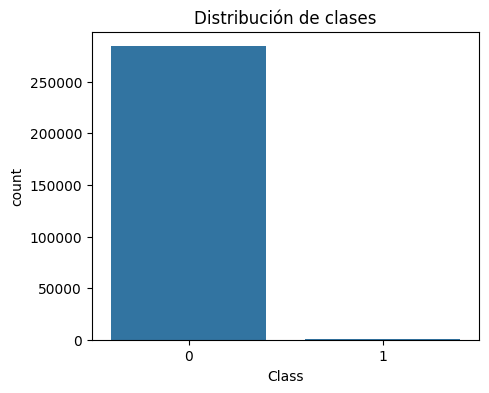

In [36]:
plt.figure(figsize=(5,4))
sns.countplot(x="Class", data=df)
plt.title("Distribución de clases")
plt.show()

In [37]:
scaler = StandardScaler()
df["Time"] = scaler.fit_transform(df[["Time"]])
df["Amount"] = scaler.fit_transform(df[["Amount"]])

In [38]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [40]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

In [41]:
print("Entrenamiento:", X_train.shape)
print("Validación:", X_val.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (182276, 30)
Validación: (45569, 30)
Prueba: (56962, 30)


In [42]:
print("\nDistribución en entrenamiento")
print(y_train.value_counts())

print("\nDistribución en validación")
print(y_val.value_counts())

print("\nDistribución en prueba")
print(y_test.value_counts())


Distribución en entrenamiento
Class
0    181961
1       315
Name: count, dtype: int64

Distribución en validación
Class
0    45490
1       79
Name: count, dtype: int64

Distribución en prueba
Class
0    56864
1       98
Name: count, dtype: int64


In [43]:
modelo_1 = Sequential([
    Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    Dense(1, activation="sigmoid")
])

modelo_1.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

modelo_1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,049 (8.00 KB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_1 = modelo_1.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/30
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - accuracy: 0.9980 - loss: 0.0109 - val_accuracy: 0.9993 - val_loss: 0.0039
Epoch 2/30
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - accuracy: 0.9994 - loss: 0.0028 - val_accuracy: 0.9991 - val_loss: 0.0041
Epoch 3/30
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.9994 - loss: 0.0025 - val_accuracy: 0.9991 - val_loss: 0.0046
Epoch 4/30
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - accuracy: 0.9994 - loss: 0.0023 - val_accuracy: 0.9992 - val_loss: 0.0040
Epoch 5/30
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - accuracy: 0.9995 - loss: 0.0022 - val_accuracy: 0.9992 - val_loss: 0.0039
Epoch 6/30
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.9995 - loss: 0.0020 - val_accuracy: 0.9993 - val_loss: 0.0039
Epoch 7/30
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.9995 - loss: 0.0019 - val_accuracy: 0.9993 - val_loss: 0.0043
Epoch 8/30
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - accuracy: 0.9996 - loss: 0

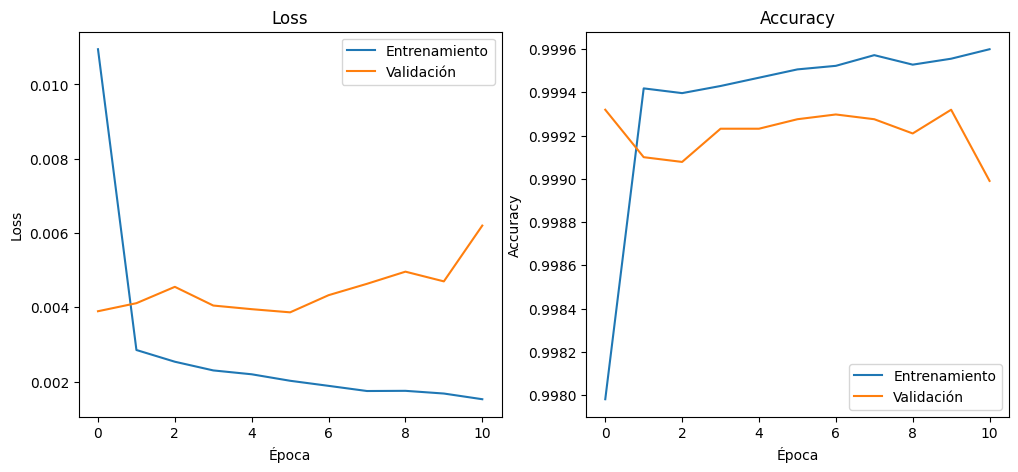

In [45]:
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history_1.history["loss"], label="Entrenamiento")
plt.plot(history_1.history["val_loss"], label="Validación")
plt.title("Loss")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history_1.history["accuracy"], label="Entrenamiento")
plt.plot(history_1.history["val_accuracy"], label="Validación")
plt.title("Accuracy")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

## 1. Classification Report

In [46]:
y_pred = (modelo_1.predict(X_test) > 0.5).astype(int)
print(classification_report(y_test, y_pred))

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.78      0.85      0.81        98

    accuracy                           1.00     56962
   macro avg       0.89      0.92      0.90     56962
weighted avg       1.00      1.00      1.00     56962



## 2. Precision, Recall, F1-score y ROC-AUC

In [47]:
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred))

Precision: 0.7757009345794392
Recall: 0.8469387755102041
F1-score: 0.8097560975609757
ROC-AUC: 0.9232583579295535


## 3. Matriz de confusión

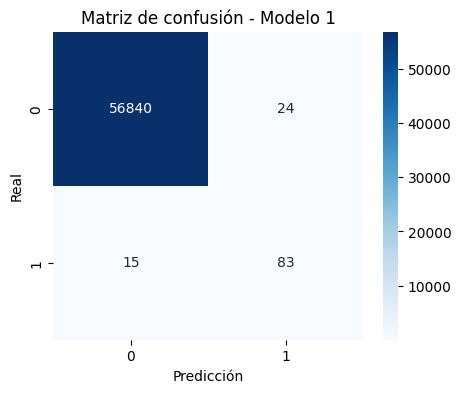

In [48]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión - Modelo 1")
plt.show()

# Modelo 2


In [49]:
modelo_2 = Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    Dense(64, activation="relu"),
    Dense(1, activation="sigmoid")
])

modelo_2.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_2 = modelo_2.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5697/5697 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - accuracy: 0.9992 - loss: 0.0052 - val_accuracy: 0.9993 - val_loss: 0.0045
Epoch 2/30
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - accuracy: 0.9994 - loss: 0.0029 - val_accuracy: 0.9993 - val_loss: 0.0043
Epoch 3/30
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.9994 - loss: 0.0027 - val_accuracy: 0.9993 - val_loss: 0.0043
Epoch 4/30
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - accuracy: 0.9995 - loss: 0.0024 - val_accuracy: 0.9993 - val_loss: 0.0042
Epoch 5/30
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - accuracy: 0.9995 - loss: 0.0022 - val_accuracy: 0.9993 - val_loss: 0.0041


## 1. Classification Report

In [50]:
y_pred = (modelo_2.predict(X_test) > 0.5).astype(int)
print(classification_report(y_test, y_pred))

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.82      0.82      0.82        98

    accuracy                           1.00     56962
   macro avg       0.91      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962



## 2. Precision, Recall, F1-score y ROC-AUC

In [53]:
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred))

Precision: 0.8163265306122449
Recall: 0.8163265306122449
F1-score: 0.8163265306122449
ROC-AUC: 0.908004992936961


## 3. Matriz de confusión

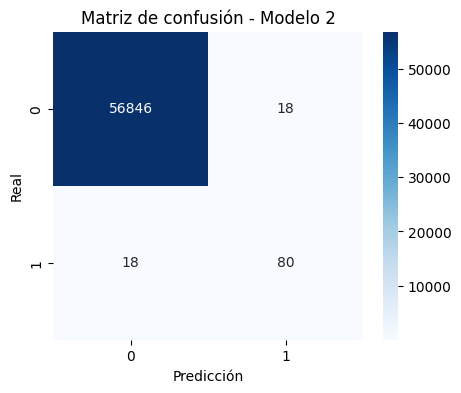

In [54]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión - Modelo 2")
plt.show()

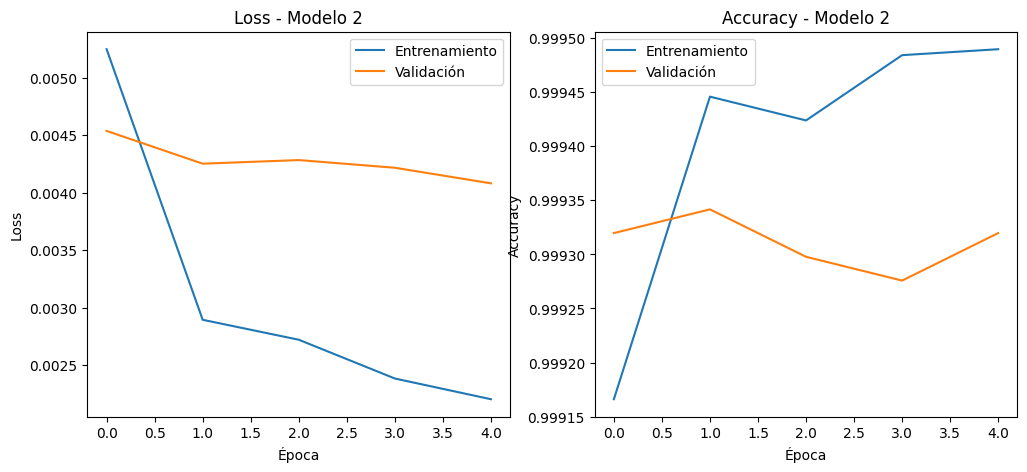

In [55]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_2.history["loss"], label="Entrenamiento")
plt.plot(history_2.history["val_loss"], label="Validación")
plt.title("Loss - Modelo 2")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_2.history["accuracy"], label="Entrenamiento")
plt.plot(history_2.history["val_accuracy"], label="Validación")
plt.title("Accuracy - Modelo 2")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

# Modelo 3

In [56]:
modelo_3 = Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

modelo_3.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_3 = modelo_3.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.9980 - loss: 0.0082 - val_accuracy: 0.9994 - val_loss: 0.0039
Epoch 2/30
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.9994 - loss: 0.0032 - val_accuracy: 0.9993 - val_loss: 0.0044
Epoch 3/30
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.9994 - loss: 0.0033 - val_accuracy: 0.9993 - val_loss: 0.0040
Epoch 4/30
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.9994 - loss: 0.0033 - val_accuracy: 0.9993 - val_loss: 0.0041
Epoch 5/30
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.9995 - loss: 0.0030 - val_accuracy: 0.9994 - val_loss: 0.0045


## 1. Classification Report

In [57]:
y_pred = (modelo_3.predict(X_test) > 0.5).astype(int)
print(classification_report(y_test, y_pred))

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.80      0.81      0.80        98

    accuracy                           1.00     56962
   macro avg       0.90      0.90      0.90     56962
weighted avg       1.00      1.00      1.00     56962



## 2. Precision, Recall, F1-score y ROC-AUC

In [58]:
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred))

Precision: 0.797979797979798
Recall: 0.8061224489795918
F1-score: 0.8020304568527918
ROC-AUC: 0.9028853663018387


## 3. Matriz de confusión

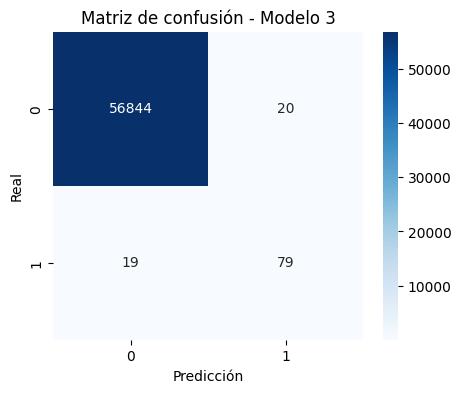

In [59]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión - Modelo 3")
plt.show()

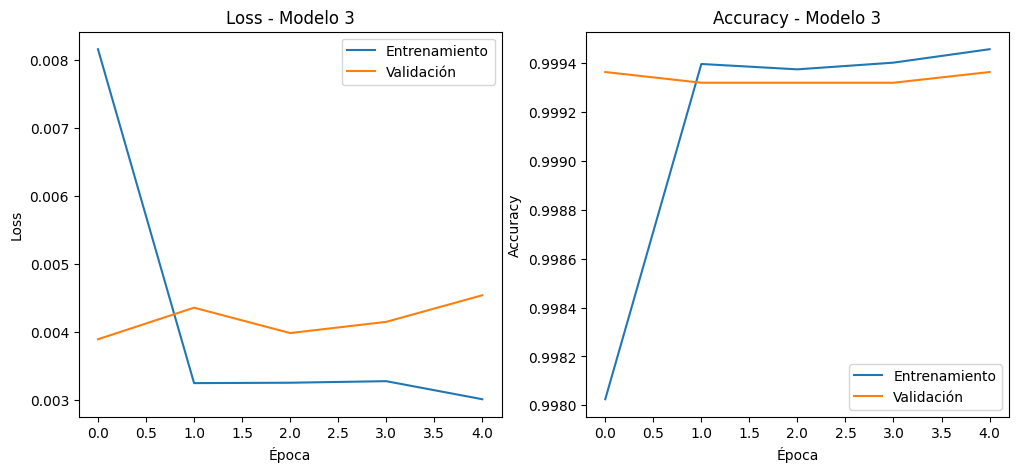

In [60]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_3.history["loss"], label="Entrenamiento")
plt.plot(history_3.history["val_loss"], label="Validación")
plt.title("Loss - Modelo 3")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_3.history["accuracy"], label="Entrenamiento")
plt.plot(history_3.history["val_accuracy"], label="Validación")
plt.title("Accuracy - Modelo 3")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

# Conclusión

En esta práctica se entrenaron tres redes neuronales con diferentes arquitecturas para detectar fraudes en transacciones bancarias y comparar cuál ofrecía un mejor desempeño. Aunque los tres modelos obtuvieron una exactitud muy alta, se observó que esta métrica por sí sola no es suficiente debido a que el conjunto de datos está muy desbalanceado. Por ello también se analizaron la precisión, el recall, el F1-score y el ROC-AUC.

Al comparar los resultados, el Modelo 1 obtuvo la mejor precisión y el mayor F1-score, mientras que el Modelo 3 logró el mayor recall y el mejor valor de ROC-AUC. Esto significa que fue el modelo que detectó la mayor cantidad de fraudes, identificando 84 de los 98 casos presentes en el conjunto de prueba, aunque también presentó un mayor número de falsos positivos.

En mi opinión, el Modelo 3 fue el mejor porque en un problema de detección de fraude es más importante detectar la mayor cantidad posible de transacciones fraudulentas, aunque algunas transacciones normales sean marcadas como sospechosas. Con esta práctica aprendí que cambiar la arquitectura de una red neuronal puede mejorar su desempeño y que es importante analizar varias métricas antes de decidir cuál modelo es el más adecuado.

## Selección de la arquitectura de la red neuronal

Para este problema se eligió una red neuronal artificial de tipo **Perceptrón Multicapa (MLP)**, ya que el conjunto de datos está formado por variables numéricas y el objetivo es realizar una clasificación binaria entre transacciones normales y fraudulentas.

Este tipo de red es adecuado para trabajar con datos tabulares, ya que permite aprender patrones complejos entre las variables de entrada y la clase objetivo. Además, se evaluaron tres arquitecturas diferentes para comparar su desempeño:

- **Modelo 1:** Una capa oculta con 64 neuronas.
- **Modelo 2:** Dos capas ocultas con 128 y 64 neuronas.
- **Modelo 3:** Tres capas ocultas con 128, 64 y 32 neuronas, además de una capa **Dropout** para reducir el sobreajuste.

No se utilizaron arquitecturas como redes convolucionales (CNN) o redes recurrentes (RNN), ya que estas son más apropiadas para imágenes o datos secuenciales. En este caso, una red neuronal artificial de tipo MLP es la opción más adecuada debido a la naturaleza del conjunto de datos.